In [ ]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
# Import numerical computation library
import numpy as np

# Import pandas for dataset handling
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced visualization
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
df = files.upload()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset (3).csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-CaseStudy2-Dataset.csv')
# Display first  rows
df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n", df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (5050, 12)

Column Names:
 Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

Data Types:

Employee_ID               object
Employee_Name             object
Age                      float64
Years_of_Experience        int64
Monthly_Salary           float64
Working_Hours_Per_Day      int64
Projects_Handled           int64
Job_Satisfaction         float64
Department                object
City                      object
Performance_Score        float64
Attrition_Flag             int64
dtype: object


In [ ]:
print(df.isnull().sum())

Employee_ID                0
Employee_Name              0
Age                      100
Years_of_Experience        0
Monthly_Salary           101
Working_Hours_Per_Day      0
Projects_Handled           0
Job_Satisfaction         101
Department                 0
City                       0
Performance_Score          0
Attrition_Flag             0
dtype: int64


In [ ]:
df.describe()

,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Performance_Score,Attrition_Flag
count,4950.000000,5050.000000,4.949000e+03,5050.000000,5050.000000,4949.000000,5050.000000,5050.000000
mean,40.005253,15.730693,9.148913e+04,8.531881,7.500198,5.585625,55.614440,0.586733
std,11.246498,11.153742,6.667466e+04,2.885185,4.069959,2.587281,19.399973,0.492469
min,21.000000,0.000000,2.500500e+04,4.000000,1.000000,1.000000,7.990000,0.000000
25%,30.000000,6.000000,5.686000e+04,6.000000,4.000000,3.380000,39.920000,0.000000
50%,40.000000,15.000000,8.996500e+04,8.000000,7.000000,5.650000,55.755000,1.000000
75%,50.000000,25.000000,1.203690e+05,11.000000,11.000000,7.810000,71.110000,1.000000
max,59.000000,39.000000,1.484850e+06,13.000000,14.000000,10.000000,104.630000,1.000000


In [ ]:
 df.dropna(inplace=True)


In [ ]:
print(df.isnull().sum())

Employee_ID              0
Employee_Name            0
Age                      0
Years_of_Experience      0
Monthly_Salary           0
Working_Hours_Per_Day    0
Projects_Handled         0
Job_Satisfaction         0
Department               0
City                     0
Performance_Score        0
Attrition_Flag           0
dtype: int64


In [ ]:
# Selecting numerical features only
X = df.drop(['Employee_ID', 'Employee_Name', 'Department', 'City'], axis=1)

# Display first 5 rows
X.head()

,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Performance_Score,Attrition_Flag
0,59.0,36,25860.0,11,13,6.37,26.50,1
1,31.0,4,69131.0,11,8,6.86,43.23,1
2,22.0,0,87955.0,9,2,2.64,43.28,1
3,42.0,14,131970.0,13,12,9.76,77.60,1
4,35.0,13,92435.0,10,4,6.33,58.22,0


**Objective:**
To group similar data points into different clusters based on their characteristics without using a target variable.

In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale the dataset
X_scaled = scaler.fit_transform(X)

# Display scaled data shape
print(X_scaled.shape)

(4749, 8)


In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Create empty list for WCSS
wcss = []

# Run loop for different k values
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Append inertia value
    wcss.append(kmeans.inertia_)

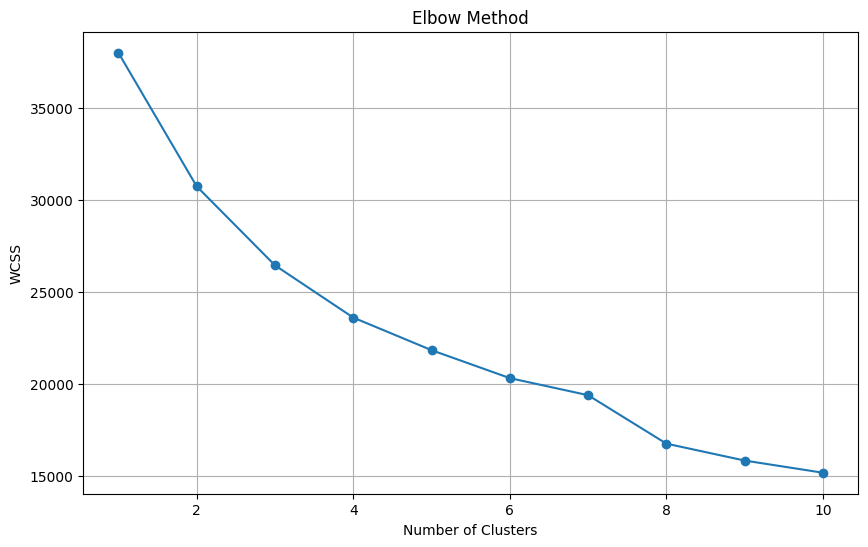

In [ ]:
# Plot elbow graph
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column into dataset
df['Cluster'] = clusters

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data
pca_components = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = clusters

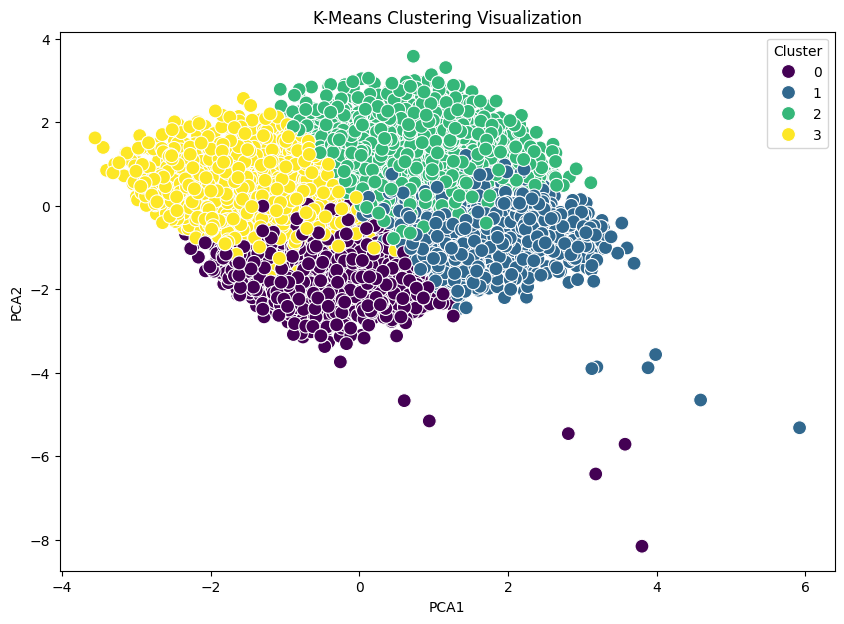

In [ ]:
# Plot clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

plt.title('K-Means Clustering Visualization')

plt.show()

In [ ]:
# Cluster-wise average values
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)

# Display analysis
print(cluster_mean)

               Age  Years_of_Experience  Monthly_Salary  \
Cluster                                                   
0        30.767018             6.648130   100901.005753   
1        50.198294            25.890192   103374.965885   
2        49.744169            25.384111    85246.922741   
3        30.459885             6.201289    81557.057307   

         Working_Hours_Per_Day  Projects_Handled  Job_Satisfaction  \
Cluster                                                              
0                     7.021093          7.770853          6.911515   
1                     6.977612          7.553305          7.062537   
2                     9.806851          7.351312          4.819934   
3                     9.429799          7.404011          4.366798   

         Performance_Score  Attrition_Flag  
Cluster                                     
0                58.654890        0.003835  
1                65.611791        0.005330  
2                55.170029        1.000000  

In [ ]:
# CLUSTER CENTERS
# ----------------------------------------

# Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

# Add cluster number
cluster_centers.index.name = 'Cluster Number'

# Display cluster centers
print("Cluster Centers:\n")
print(cluster_centers)

Cluster Centers:

                      Age  Years_of_Experience  Monthly_Salary  \
Cluster Number                                                   
0               30.756238             6.640115   100901.473129   
1               50.189563            25.878594   103371.812567   
2               49.734159            25.376548    85257.533867   
3               30.455914             6.194982    81543.968459   

                Working_Hours_Per_Day  Projects_Handled  Job_Satisfaction  \
Cluster Number                                                              
0                            7.022073          7.770633          6.913733   
1                            6.976571          7.553781          7.059915   
2                            9.807720          7.351784          4.822840   
3                            9.428674          7.403584          4.363613   

                Performance_Score  Attrition_Flag  
Cluster Number                                     
0                 

In [ ]:
# PCA CLUSTER VISUALIZATION
# ===========================================

# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data into 2 dimensions
pca_components = pca.fit_transform(X_scaled)

# Create dataframe for PCA
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Display first 5 rows
print(pca_df.head())

       PCA1      PCA2  Cluster
0  1.114554  2.630396        2
1 -1.590608  0.225028        3
2 -2.474945  0.169909        3
3  0.548894 -0.267575        2
4 -0.062242 -0.851373        0


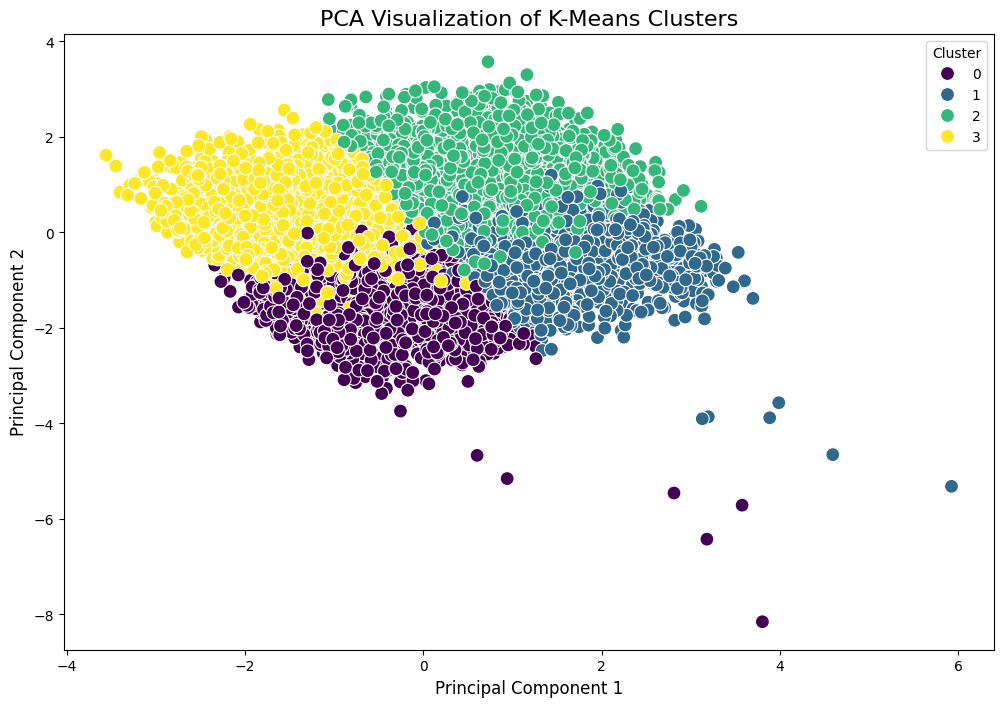

In [ ]:
# PCA SCATTER PLOT
# ===========================================

# Set figure size
plt.figure(figsize=(12,8))

# Create scatter plot
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

# Plot title
plt.title('PCA Visualization of K-Means Clusters', fontsize=16)

# X-axis label
plt.xlabel('Principal Component 1', fontsize=12)

# Y-axis label
plt.ylabel('Principal Component 2', fontsize=12)

# Show legend
plt.legend(title='Cluster')

# Show graph
plt.show()

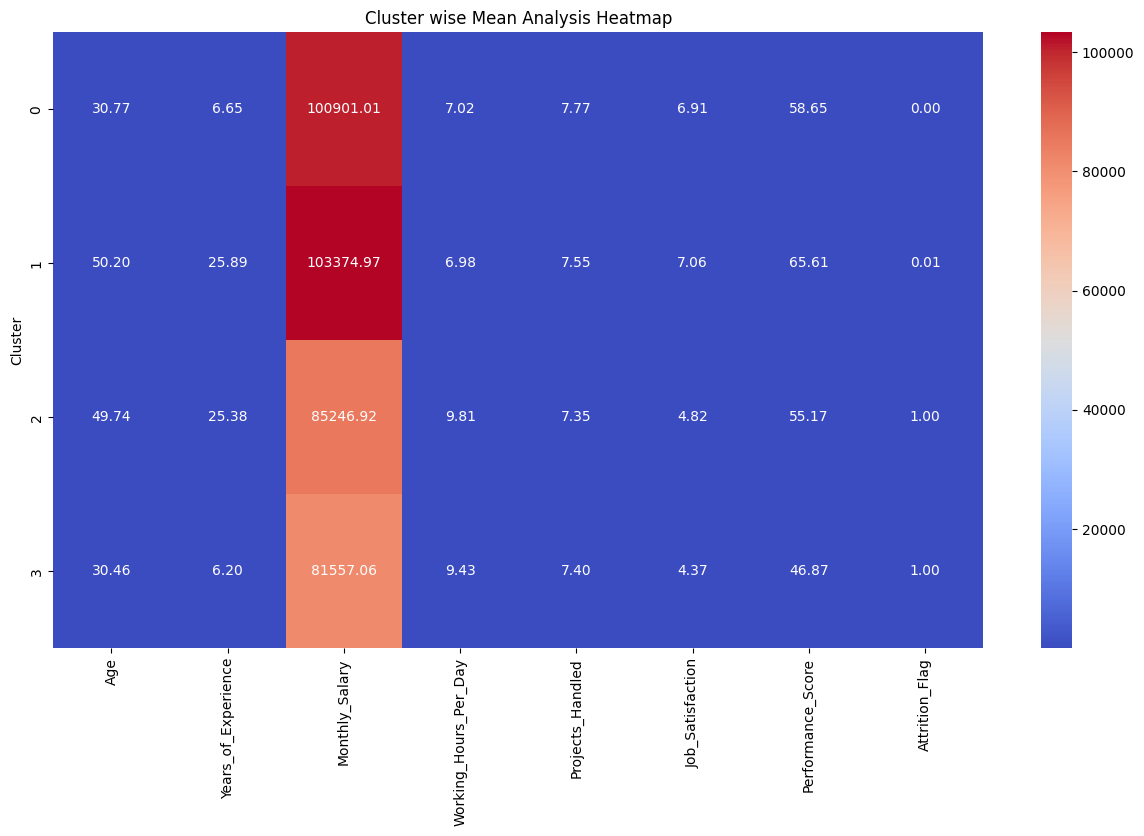

In [ ]:
# HEATMAP OF CLUSTER MEANS
# ===========================================

# Set figure size
plt.figure(figsize=(15,8))

# Create heatmap
sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Title
plt.title('Cluster wise Mean Analysis Heatmap')

# Show graph
plt.show()

**Conclusion:**

The K-Means clustering algorithm successfully segmented employees into four distinct groups based on age, experience, salary, working hours, job satisfaction, performance score, and attrition status. PCA visualization showed clear cluster separation, indicating meaningful employee groupings.

Cluster 1 consisted of older and highly experienced employees (Age ≈ 50.20, Experience ≈ 25.89 years) with the highest salary (₹103,375), highest performance score (65.61), high job satisfaction (7.06), and almost no attrition (0.005). Cluster 0 included younger employees (Age ≈ 30.77, Experience ≈ 6.65 years) with good salaries (₹100,901), moderate performance (58.65), high job satisfaction (6.91), and very low attrition (0.004).

In contrast, Clusters 2 and 3 showed 100% attrition. Cluster 2 contained experienced employees (Age ≈ 49.74, Experience ≈ 25.38 years) working the longest hours (9.81 hours/day), with lower job satisfaction (4.82) and lower salary (₹85,247). Cluster 3 consisted of younger employees (Age ≈ 30.46, Experience ≈ 6.20 years) with the lowest salary (₹81,557), lowest job satisfaction (4.37), lowest performance score (46.87), and complete attrition.

Overall, the clustering results indicate that higher job satisfaction, better salaries, and balanced working hours are associated with lower attrition, while lower satisfaction and longer working hours are linked to higher employee turnover. K-Means effectively identified employee segments and provided valuable insights into factors influencing attrition.
